# Homework 5: Model Selection and Extreme Values

BEE 4850/5850, Spring 2025

**Name**: Christine Swanson 

**ID**: cms549

> **Due Date**
>
> Friday, 5/2/25, 9:00pm

## Overview

### Instructions

The goal of this homework assignment is to practicing approaches to
extreme value analysis and using information criteria to assess evidence
for models.

-   Problem 1 asks you to compare stationary and non-stationary block
    maxima models for daily maximum temperature data.
-   Problem 2 asks you to use peaks-over-thresholds modeling on the same
    dataset from Problem 1.
-   Problem 3 (only required for students in BEE 5850) asks you to
    compare several linear regression models for environmental
    influences on non-accidental death data.

### Load Packages

The following packages are included in the environment (to help you find
other similar packages in other languages). The code below loads these
packages for use in the subsequent notebook (the desired functionality
for each package is commented next to the package).

In [1]:
import random  # random number generation and seed-setting
import pandas as pd  # tabular data structure (similar to DataFrames)
import numpy as np  # numerical operations
import csv  # reads/writes .csv files
import scipy.stats as stats  # interface to work with probability distributions
import matplotlib.pyplot as plt  # plotting library
import seaborn as sns  # additional statistical plotting tools
from datetime import datetime, timedelta  # date and time handling

## Problems

### Scoring

-   Problem 1 is worth 10 points;
-   Problem 2 is worth 10 points;
-   Problem 3 is worth 5 points;

### Problem 1

Let’s look at how (modeled) annual maximum temperatures have (or have
not) increased in Ithaca from 1850–2014. Model output from NOAA’s
GFDL-ESM4 climate model (one of the models used in the latest Climate
Model Intercomparison Project,
[CMIP6](https://colab.research.google.com/corgiredirector?site=https%3A%2F%2Fcds.climate.copernicus.eu%2Fcdsapp%23%21%2Fdataset%2Fprojections-cmip6%3Ftab%3Doverview))
is available in `data/gfdl-esm4-tempmax-ithaca.csv`. While this model
output has not been bias-corrected, we won’t worry about that for the
purposes of this assignment. The temperature data is in degrees Celsius,
and the dates are provided as calendar dates.

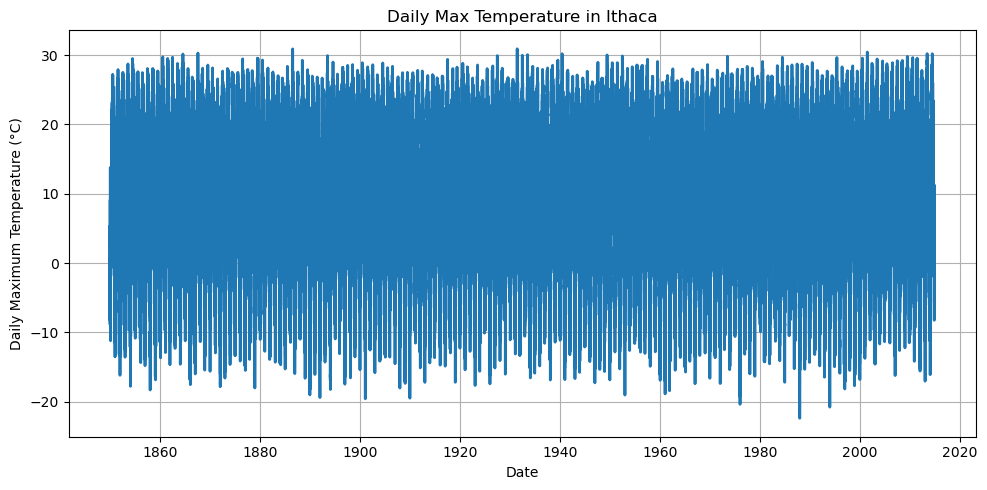

In [ ]:
# adapted from ChatGPT (see references)
# Read the CSV file into a DataFrame
ithaca_dat = pd.read_csv("data/gfdl-esm4-tempmax-ithaca.csv")

# Convert the 'Day' column to datetime if it's not already
ithaca_dat['Day'] = pd.to_datetime(ithaca_dat['Day'])

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(ithaca_dat['Day'], ithaca_dat['TempMax'], linewidth=2)
plt.xlabel("Date")
plt.ylabel("Daily Maximum Temperature (°C)")
plt.title("Daily Max Temperature in Ithaca")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load the (daily maximum) temperature data from
    `data/gfdl-esm4-tempmax-ithaca.csv`. Find the modeled annual maximum
    temperatures and plot them.
-   Fit a stationary GEV model to the annual maximum series and report
    your parameter estimates. Plot the fitted distribution along with
    the data. What type of GEV distribution did you end up with? What is
    the 100-year return level?
-   Now fit a nonstationary GEV with respect to time (only the location
    parameter should be non-stationary),
    $y \sim \text{GEV}(\mu_0 + \mu_1 t, \sigma, \xi)$ (for scaling
    purposes, begin with $t=0$ corresponding to 1850).
-   What are the AIC values for each model? What can you conclude about
    the relative evidence for non-stationarity?


### Problem 2

Now let’s analyze how often of the Ithaca temperature data.

**In this problem**:

-   Suppose that we were interested in looking at temperature
    exceedances over 28°C. Decluster these occurrences and plot the
    number of exceedances by year. Have they increased over time?
-   Fit a stationary Poisson-GPD model for the exceedances. What does
    the GPD distribution look like?
-   From your model, estimate the 100-year return level. How does it
    differ from the 100-year return period from the stationary model in
    Problem 1? Why do you think it agrees or disagrees?

### Problem 3

**This problem is only required for students in BEE 5850**.

Let’s examine the influence of air pollution and temperature on
mortality in Chicago, IL. The `data/chicago.csv` dataset (originally
from the [`gamair` `R`
package](https://cran.r-project.org/web/packages/gamair/index.html))contains
data on the relationship between environmental conditions (temperature
and air quality) and deaths in Chicago from 1987–2000. The variables
are:

-   the total number of (non-accidental) deaths each day (`death`);
-   the median density over the city of large pollutant particles (PM10;
    `pm10median`);
-   the median density of smaller pollutant particles (PM2.5;
    `pm25median`);
-   the median concentration of ozone (O$_3$) in the air (`o3median`);
    the median concentration of sulfur dioxide (SO$_2$) in the air
    (`so2median`);
-   the time in days (`time`); and the daily mean temperature (`tmpd`).

The pollution variables have been standardized to represent deviations
from the overall median and the temperature is in Fahrenheit. The days
are given as a number of days relative to December 31, 1993. Note that
some values are missing; these can be treated as missing at random and
dropped in your regressions.

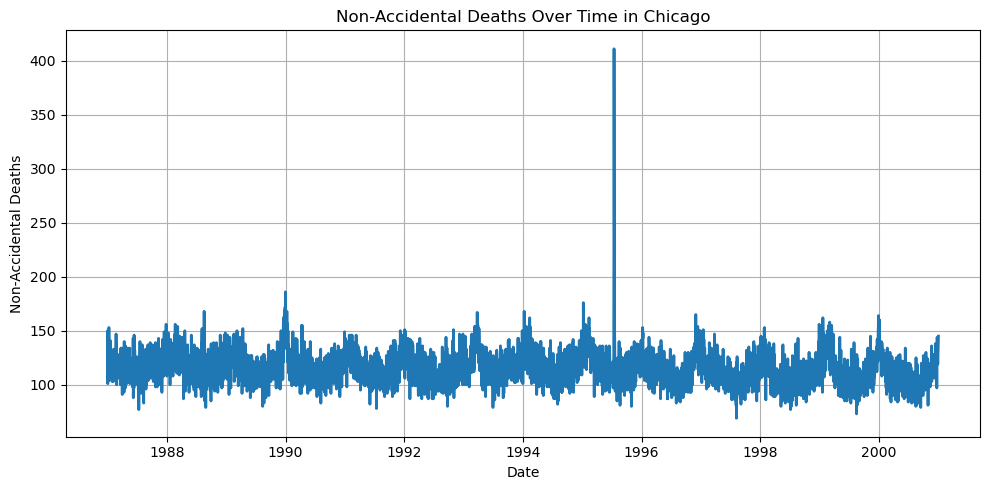

In [3]:
# adapted from ChatGPT (see references)
# Read the CSV file with specified delimiter and NA values
chicago_dat = pd.read_csv("data/chicago.csv", delimiter=',', header=0, na_values="NA")

# Define the reference date
day_zero = datetime.strptime("1993-12-31", "%Y-%m-%d")

# Add fractional day offset (0.5 days = 12 hours), then compute full dates
chicago_dat['Date'] = chicago_dat['time'].apply(lambda t: day_zero + timedelta(days=t + 0.5))

# Plot the data
plt.figure(figsize=(10, 5))
plt.plot(chicago_dat['Date'], chicago_dat['death'], linewidth=2)
plt.xlabel("Date")
plt.ylabel("Non-Accidental Deaths")
plt.title("Non-Accidental Deaths Over Time in Chicago")
plt.grid(True)
plt.tight_layout()
plt.show()

**In this problem**:

-   Load and plot the deaths data. Linearly regress the number of deaths
    against time and report the coefficients for the fitted model. Add
    the regression line to your plot. What does this regression tell
    you?
-   Now linearly regress the deaths data against temperature. Once
    again, report the coefficients, and add the regression line to your
    plot. What does this regression tell you about the influence of
    temperature?
-   Expand your previous model by regressing deaths against temperature
    and PM2.5 density. Report the coefficients and add this regression
    line to your plot.
-   Compute the AICs for the three fitted model and compare them. What
    do they tell you about the relative evidence for the influence of
    temperature and PM2.5 density on deaths? How do your conclusions
    based on AIC compare to those you might draw from your regression
    coefficients and plots?

## References and Generative AI Acknowledgement 

OpenAI. (2025). ChatGPT (April 14 version) [Large language model]. https://openai.com/chatgpt [Accessed 14 April 2025]. 

- Problem 0: Setting up packages
    - Prompt I asked ChatGPT: "Convert these Julia packages to Python". That is, I asked it to convert the provided Julia packages to Python.
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 1: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `ithaca_dat = CSV.read("data/gfdl-esm4-tempmax-ithaca.csv", DataFrame)
plot(ithaca_dat.Day, ithaca_dat.TempMax, lw=2, xlabel="Date", ylabel="Daily Maximum Temperature (°C)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT

- Problem 3: Converting provided Julia code to Python
    - Prompt I asked ChatGPT: "Convert this Julia code to Python: `chicago_dat = CSV.read("data/chicago.csv", DataFrame; delim=',', header=true, missingstring="NA")
day_zero = Date("1993-12-31")
chicago_dat.Date = day_zero .+ Day.(chicago_dat.time .+ 0.5)
plot(chicago_dat.Date, chicago_dat.death, lw=2, xlabel="Date", ylabel="Non-Accidental Deaths)", legend=false)`
    - Date of prompt: 14 April 2025
    - Verified the code made sense and used directly from ChatGPT